# Avance 2: Ingeniería de características

# **Procesamiento de Lenguaje Natural**


## Maestría en Inteligencia Artificial Aplicada
### Tecnológico de Monterrey

* **Nombres y matrículas**
    * Sarmiento Cervantes Jacqueline: A01795863
    * Mayoral Terán Alexandro: A01795899
* **Número de equipo: 8**

En este avance se transforma el corpus regulatorio, los formularios existentes y sus catálogos asociados en representaciones útiles para recuperación semántica y generación posterior de formularios.

La ingeniería de características se aborda en tres niveles:

1. Características estructurales: documento, sección, campo, catálogo.
2. Características textuales: longitud, términos relevantes, presencia de artículos, presencia de tablas.
3. Representaciones vectoriales: TF-IDF y embeddings semánticos.

In [71]:
from pathlib import Path
import re
import os
import sys
import json
import warnings
import time
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


sns.set_theme(style='whitegrid', palette='Dark2')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)


warnings.filterwarnings("ignore")



In [2]:
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

In [3]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "02_interim"
DATA_OUTPUT = PROJECT_ROOT / "data" / "03_output"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_INTERIM.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

## Conversión de PDFs a Mardown a través de la herramienta Blazedocs

Los documentos regulatorios originales se encuentran en formato PDF. Para facilitar su análisis dentro de un flujo de NLP, se convierten a Markdown, ya que este formato conserva mejor la estructura lógica del documento, incluyendo encabezados, párrafos y tablas.

En este proyecto se utiliza BlazeDocs para la conversión de PDFs a Markdown mediante la API de la aplicación, utilizando el siguiente código:

In [4]:
import requests

BLAZEDOCS_API_URL = "https://blazedocs.io/api/v1/convert"

# Folder con pdfs originales
PDF_INPUT_DIR = DATA_RAW / "pdfs"

# Folder con formularios originales
FORM_INPUT_DIR = DATA_RAW / "formularios"

# Folder con catálogos originales
CAT_INPUT_DIR = DATA_RAW / "catalogos"

# Folder donde se guardan archivos markdown
MARKDOWN_OUTPUT_DIR = DATA_INTERIM / "markdown"

# Folder donde se guardan dataframes
DF_OUTPUT_DIR = DATA_INTERIM / "dataframes"

#Folder base datos vectorizada chroma
CHROMA_PERSIST_DIR = DATA_OUTPUT / "chroma_db"

# Crear folder si no existe
PDF_INPUT_DIR.mkdir(parents=True, exist_ok=True)
FORM_INPUT_DIR.mkdir(parents=True, exist_ok=True)
CAT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
MARKDOWN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_PERSIST_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"PDF input folder: {PDF_INPUT_DIR}")
print(f"Forms input folder: {FORM_INPUT_DIR}")
print(f"Catalogs input folder: {CAT_INPUT_DIR}")

print(f"Markdown output folder: {MARKDOWN_OUTPUT_DIR}")
print(f"Dataframes output folder: {DF_OUTPUT_DIR}")
print(f"CHROMA output folder: {CHROMA_PERSIST_DIR}")

Project root: /content
PDF input folder: /content/data/01_raw/pdfs
Forms input folder: /content/data/01_raw/formularios
Catalogs input folder: /content/data/01_raw/catalogos
Markdown output folder: /content/data/02_interim/markdown
Dataframes output folder: /content/data/02_interim/dataframes
CHROMA output folder: /content/data/03_output/chroma_db


**Conexión con API Key de BlazeDocs**

In [125]:
import dotenv
dotenv_path = PROJECT_ROOT / "env.txt"
dotenv.load_dotenv(dotenv_path=dotenv_path)

def get_blazedocs_api_key() -> str:
    """
    Se toma la API key de BlazeDocs desde una variable de ambiente
    """
    api_key = os.getenv("BLAZEDOCS_API_KEY")

    if not api_key:
        raise ValueError(
            "No se encontró la API key")

    return api_key

**Conversión de PDF a formato Markdown**

Se desarrollaron diversas funciones para realizar la conversión de los pdf's a formato Markdown, las cuales son importan a continuación

In [ ]:
from src.ingesta.blazedocs_pdf_to_md import convert_pdf_folder_to_markdown, save_markdown, convert_pdf_folder_to_markdown

**Conversión de archivos**

En este paso se realiza la conversión de los archivos pdf encontrados en el directorio a Markdown:

In [ ]:
conversion_log = convert_pdf_folder_to_markdown(
    input_dir=PDF_INPUT_DIR,
    output_dir=MARKDOWN_OUTPUT_DIR,
    overwrite=False
)

Se observa que la conversión fue exitosa

In [127]:
conversion_log

,file_name,output_file,status,page_count,token_count,processing_time_ms,error
0,LeyInstCredito_93-110.pdf,LeyInstCredito_93-110.md,success,18,14503,5620,NaN
1,Circular3-2012.pdf,Circular3-2012.md,success,313,173386,38341,NaN
2,Anexo_33_CUB.pdf,Anexo_33_CUB.md,success,100,78013,14063,NaN
3,CUB_extracto.pdf,CUB_extracto.md,success,29,18750,6774,NaN
4,Disposiciones_Liquidez.pdf,Disposiciones_Liquidez.md,success,73,46406,9632,NaN
5,Intraday_Liquidity_esp.pdf,Intraday_Liquidity_esp.md,success,26,10350,5090,NaN


---

In [ ]:
############### FUNCIONES A OCUPAR (SE DEBEN ELIMINAR PARA LA ENTREGA Y PASARLAS AL REPO)##################################################

Funciones limpieza

In [6]:
def limpieza_universal(texto: str) -> str:
    """
    Limpieza genérica aplicable a cualquier documento normativo extraído.
    Elimina caracteres residuales, dobles espacios y saltos de línea excesivos.
    """
    # Eliminar símbolos residuales extraños de parsers OCR o PDF
    texto = re.sub(r'\^\{\}|\[\]', '', texto)
    texto = re.sub(r'\x0c', ' ', texto) # Saltos de página ocultos

    # Limpiar los saltos de línea excesivos (más de 2 seguidos se vuelven 2)
    texto = re.sub(r'\n{3,}', '\n\n', texto)

    # Quitar espacios múltiples horizontales
    texto = re.sub(r'[ \t]+', ' ', texto)
    return texto.strip()

def limpiar_ruido_cnbv(texto_md: str) -> str:
    """
    Limpia el ruido específico de documentos de la CNBV (ej. Circular Única de Bancos).
    """
    texto = texto_md

    # Quitar las marcas de control de la CNBV al inicio de línea (ej: "(274) ", "(214) ")
    texto = re.sub(r'^\(\d+\)\s*', '', texto, flags=re.MULTILINE)

    # Quitar el pie de página recurrente (dirección y teléfonos de CNBV)
    texto = re.sub(r'Insurgentes Sur 1971.*?www\.gob\.mx/cnbv', '', texto, flags=re.DOTALL)

    # Quitar encabezados institucionales repetitivos de CNBV / SHCP
    patrones = [
        r'^Hacienda Secretaria de Hacienda y Credito Publico$',
        r'^Hacienda Secretaría de Hacienda y Crédito Público$',
        r'^CNBV$',
        r'^CONSEJO NACIONAL.*$'
    ]

    for patron in patrones:
        texto = re.sub(patron, '', texto, flags=re.MULTILINE)

    return texto.strip()

def limpiar_ruido_banxico(texto: str) -> str:
    """
    Limpia ruido específico de documentos del Banco de México (Circulares, disposiciones, etc.)
    Mantiene la estructura normativa (artículos, títulos), eliminando contenido no informativo.
    """
    texto_limpio = texto

    # 1 Eliminar encabezado institucional repetido
    texto_limpio = re.sub(
        r'BANCO\s+DE\s+M[ÉE]XICO.*?\n',
        '',
        texto_limpio,
        flags=re.IGNORECASE)

    # Eliminar bloque de "TEXTO COMPILADO..."
    # (muy largo, no aporta valor semántico)
    texto_limpio = re.sub(
        r'TEXTO\s+COMPILADO.*?respectivamente\.',
        '',
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Eliminar notas de modificación
    texto_limpio = re.sub(
        r'\(Modificado.*?\)',
        '',
        texto_limpio,
        flags=re.IGNORECASE
    )

    # 4. Eliminar números de página aislados
    texto_limpio = re.sub(
        r'\n\s*\d+\s*\n',
        '\n',
        texto_limpio)

    # Normalizar artículos (quitar numeración duplicada tipo "(275)")
    texto_limpio = re.sub(
        r'\(\d+\)\s*Artículo',
        'Artículo',
        texto_limpio)

    # Eliminar líneas completamente en blanco múltiples
    texto_limpio = re.sub(
        r'\n{3,}',
        '\n\n',
        texto_limpio)

    # Normalizar espacios
    texto_limpio = re.sub(
        r'[ \t]+',
        ' ',
        texto_limpio)

    return texto_limpio.strip()

def limpiar_ruido_dof(text: str) -> str:
    text = text.replace('\n', ' ')

    # Quitar encabezados institucionales repetitivos de CNBV / SHCP
    patterns_headers = [
        r'CÁMARA DE DIPUTADOS.*?SERVICIOS PARLAMENTARIOS',
        r'LEY DE INSTITUCIONES DE CRÉDITO',
        r'ESTADOS UNIDOS MEXICANOS',
        r'Última Reforma DOF.*?\d{4}'
    ]

    for p in patterns_headers:
        text = re.sub(p, '', text, flags=re.IGNORECASE)

    # Remover anotaciones legales
    patterns_dof = [
        r'Párrafo reformado DOF.*?\d{4}',
        r'Artículo reformado DOF.*?\d{4}',
        r'Artículo adicionado DOF.*?\d{4}',
        r'Fracción reformada DOF.*?\d{4}',
        r'Fracción adicionada DOF.*?\d{4}',
        r'Reforma DOF.*?\d{4}',
        r'Derogado DOF.*?\d{4}'
    ]

    for p in patterns_dof:
        text = re.sub(p, '', text)

    # Remover número de páginas
    text = re.sub(r'\d+\s+de\s+\d+', '', text)

    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text)

    # Preservar estructura: artículos
    text = re.sub(r'(Artículo\s+\d+\s*(Bis)?\.?)', r'\n\1', text)

    # Preservar números romanos (fracciones)
    text = re.sub(r'\s([IVX]+\.)', r'\n\1', text)

    return text.strip()


def limpiar_ruido_basel(texto: str) -> str:
    """
    Limpia ruido documental típico de documentos del Comité de Basilea/BIS traducidos al español.
    Conserva el contenido normativo principal y elimina portada, avisos, pies de página,
    numeración, ISBN e información editorial.
    """

    texto_limpio = texto

    # Nota de traducción en portada
    texto_limpio = re.sub(
        r"Traducción al español generada.*?Marco de Basilea consolidado\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Encabezado/pie repetido con título del documento
    texto_limpio = re.sub(
        r"Herramientas de monitoreo para la gestión de la liquidez intradía\s*-\s*traducción al español",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Números de página tipo: Página 1 de 16
    texto_limpio = re.sub(
        r"Página\s+\d+\s+de\s+\d+",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Texto editorial de disponibilidad
    texto_limpio = re.sub(
        r"Esta publicación está disponible en el sitio web del BIS.*?\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # Copyright / derechos reservados
    texto_limpio = re.sub(
        r"©\s*Banco de Pagos Internacionales\s+2013\..*?cite la fuente\.",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.DOTALL)

    # ISBN
    texto_limpio = re.sub(
        r"ISBN\s+[\d\-Xx]+\s*\(?(impreso|en línea|online|print)?\)?",
        "",
        texto_limpio,
        flags=re.IGNORECASE)

    # Eliminar línea de institución si aparece aislada
    texto_limpio = re.sub(
        r"^\s*Comité de Basilea\s+de Supervisión Bancaria\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    # Eliminar tabla de contenido / índice con puntos y número de página
    # Ejemplo: "I. Introducción ........................................ 1"
    texto_limpio = re.sub(
        r"^\s*(Contenido|Índice)\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    texto_limpio = re.sub(
        r"^\s*[IVXLCDM]+\.\s+.*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE)

    texto_limpio = re.sub(
        r"^\s*[A-Z]\.\s+.*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE )

    texto_limpio = re.sub(
        r"^\s*Anexo\s+\d+\..*?\.{3,}\s*\d+\s*$",
        "",
        texto_limpio,
        flags=re.IGNORECASE | re.MULTILINE )

    # Quitar números de página aislados
    texto_limpio = re.sub(
        r"\n\s*\d+\s*\n",
        "\n",
        texto_limpio)

    # Normalizar viñetas: mantenerlas, pero limpiar espacios
    texto_limpio = re.sub(
        r"\n\s*[•●]\s*",
        "\n- ",
        texto_limpio)

    # Normalizar espacios y saltos
    texto_limpio = re.sub(r"[ \t]+", " ", texto_limpio)
    texto_limpio = re.sub(r"\n{3,}", "\n\n", texto_limpio)

    return texto_limpio.strip()


def procesar_documento(texto: str, origen: str = "CNBV") -> str:
    if origen.upper() == "CNBV":
        texto = limpieza_universal(limpiar_ruido_cnbv(texto))
    if origen.upper() == "BANXICO":
        texto = limpieza_universal(limpiar_ruido_banxico(texto))
    if origen.upper() == "DOF":
        texto = limpieza_universal(limpiar_ruido_dof(texto))
    if origen.upper() == "BASEL":
        texto = limpieza_universal(limpiar_ruido_basel(texto))
    return limpieza_universal(texto)

In [25]:
def leer_excel_multipestana(path_excel: str, tipo: str) -> dict:
    """
    Función para leer cada pestaña de un excel
    path_excel : Ruta del archivo Excel.
    tipo : 'formulario' o 'catalogo', solo para metadatos.

    Devuelve un diccionario de dataframes donde cada una corresponde a una sección o un catálogo

    """
    path_excel = Path(path_excel)

    if not path_excel.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path_excel}")

    xls = pd.ExcelFile(path_excel)
    tablas = {}

    for sheet in xls.sheet_names:
        df = pd.read_excel(path_excel, sheet_name=sheet)

        # Limpieza básica de nombres de columnas
        df.columns = [
            str(c).strip().lower().replace(" ", "_")
            for c in df.columns
        ]

        # Eliminar filas completamente vacías
        df = df.dropna(how="all").reset_index(drop=True)

        # Guardar metadatos útiles
        df.attrs["archivo"] = path_excel.name
        df.attrs["tipo"] = tipo
        df.attrs["sheet"] = sheet

        tablas[sheet] = df

    return tablas

In [7]:
def construir_dataset_campos(formularios: dict) -> pd.DataFrame:
    registros = []

    for seccion, df in formularios.items():
        columnas_catalogo = [c for c in df.columns if "catalogo" in c]

        for idx, row in df.iterrows():
            catalogos_asociados = [
                str(row[c]).strip()
                for c in columnas_catalogo
                if c in row and pd.notna(row[c])
            ]

            texto_campo = " | ".join([
                str(row.get("etiqueta", "")),
                str(row.get("descripcion", "")),
                str(row.get("tipo_dato", "")),
                " ".join(catalogos_asociados)
            ])

            registros.append({
                "tipo_documento": "formulario",
                "seccion": seccion,
                "campo": row.get("etiqueta", None),
                "descripcion": row.get("descripcion", None),
                "tipo_dato": row.get("tipo_dato", None),
                "catalogos_asociados": catalogos_asociados,
                "n_catalogos_asociados": len(catalogos_asociados),
                "texto_representacion": texto_campo,
                "n_caracteres": len(texto_campo),
                "n_palabras": len(re.findall(r"\b\w+\b", texto_campo))
            })

    return pd.DataFrame(registros)

In [8]:
def construir_dataset_catalogos(catalogos: dict) -> pd.DataFrame:
    registros = []

    for nombre_catalogo, df in catalogos.items():
        columnas_textuales = [
            c for c in df.columns
            if df[c].dtype == "object" or pd.api.types.is_string_dtype(df[c])
        ]

        texto_catalogo = " ".join(
            df[columnas_textuales]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
            .tolist()
        ) if columnas_textuales else ""

        registros.append({
            "tipo_documento": "catalogo",
            "catalogo": nombre_catalogo,
            "n_registros": len(df),
            "n_columnas": df.shape[1],
            "columnas": ", ".join(df.columns),
            "texto_representacion": texto_catalogo,
            "n_caracteres": len(texto_catalogo),
            "n_palabras": len(re.findall(r"\b\w+\b", texto_catalogo))
        })

    return pd.DataFrame(registros)

In [9]:
##### Chunks por párrafo
def chunking_por_parrafo(texto: str, min_palabras: int = 20) -> list:
    chunks = []

    for bloque in re.split(r"\n\s*\n", texto):
        bloque = bloque.strip()
        n_palabras = len(re.findall(r"\b\w+\b", bloque))

        if n_palabras >= min_palabras:
            chunks.append(bloque)

    return chunks

In [10]:
##### Chunks fijos con overlap
def chunking_fijo_overlap(texto: str, chunk_size: int = 300, overlap: int = 50) -> list:
    palabras = re.findall(r"\b\w+\b", texto)
    chunks = []

    start = 0
    while start < len(palabras):
        end = start + chunk_size
        chunk = " ".join(palabras[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap

    return chunks

In [11]:
##### Chunking estructural por títulos/artículos
def chunking_estructural(texto: str) -> list:
    patron = r"(?=(?:Artículo\s+\d+|TÍTULO\s+[A-ZÁÉÍÓÚÑ]+|CAPÍTULO\s+[A-ZÁÉÍÓÚÑ]+|Apartado\s+[A-Z]))"
    partes = re.split(patron, texto)

    chunks = []
    for parte in partes:
        parte = parte.strip()
        if len(parte.split()) >= 20:
            chunks.append(parte)

    return chunks

In [12]:
def normalizar_headers_regulatorios(texto: str) -> str:

    # TÍTULOS
    texto = re.sub(
        r'^(TÍTULO\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'# \1',
        texto,
        flags=re.MULTILINE
    )
    texto = re.sub(
        r'^(Título\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'# \1',
        texto,
        flags=re.MULTILINE
    )
    # ANEXOS
    texto = re.sub(
        r'^(ANEXO\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'# \1',
        texto,
        flags=re.MULTILINE
    )
    texto = re.sub(
        r'^(Anexo\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'# \1',
        texto,
        flags=re.MULTILINE
    )

    # CAPÍTULOS
    texto = re.sub(
        r'^(CAPÍTULO\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'## \1',
        texto,
        flags=re.MULTILINE
    )
    texto = re.sub(
        r'^(Capítulo\s+[A-ZÁÉÍÓÚÑ]+.*)$',
        r'## \1',
        texto,
        flags=re.MULTILINE
    )

    # ARTÍCULOS
    texto = re.sub(
        r'^(ARTÍCULO\s+\d+.*)$',
        r'### \1',
        texto,
        flags=re.MULTILINE
    )
    texto = re.sub(
        r'^(Artículo\s+\d+.*)$',
        r'### \1',
        texto,
        flags=re.MULTILINE
    )

    return texto

In [13]:
def chunking_encabezados_md(texto: str, chunk_size: int = 500, overlap: int = 80) -> list:
#def crear_chunks_markdown(texto: str, chunk_size: int = 500, overlap: int = 80) -> list:
    """
    Lee un archivo Markdown, aplica limpieza de ruido OCR y fragmenta el texto
    basándose en la jerarquía de los encabezados (Títulos, Capítulos, Artículos).
    """

    texto = normalizar_headers_regulatorios(texto)

    # Definir los niveles de encabezados por los que queremos cortar.
    # Esto preservará el artículo o sección completa.
    headers_to_split_on = [
        ("#", "Header 1"),      # Ej: Títulos / Anexos
        ("##", "Header 2"),     # Ej: Capítulos
        ("###", "Header 3"),    # Ej: Secciones
        ("####", "Header 4"),   # Ej: Artículos
    ]

    # Inicializar el Text Splitter
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on,
        strip_headers=False # Mantener el encabezado dentro del chunk es útil para dar contexto al LLM
    )

    # Dividir el texto
    documentos = markdown_splitter.split_text(texto)

    # dividir chunks gigantes manteniendo contexto
    recursive_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap
    )

    chunks_finales = []

    for doc in documentos:

        subchunks = recursive_splitter.split_text(doc.page_content)

        for chunk in subchunks:

          chunks_finales.append(chunk)


            # chunks_finales.append({
            #     "texto": chunk,
            #     "metadata": doc.metadata
            # })

    return chunks_finales

In [14]:
def top_tfidf_terms(vectorizer, X, top_n=25):
    feature_names = np.array(vectorizer.get_feature_names_out())
    scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = scores.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "termino": feature_names[top_idx],
        "score_promedio_tfidf": scores[top_idx]
    })

In [15]:
def buscar_tfidf(query: str, vectorizer, X, df_base: pd.DataFrame, k: int = 5):
    q_vec = vectorizer.transform([query])
    sims = cosine_similarity(q_vec, X).ravel()
    top_idx = sims.argsort()[::-1][:k]

    resultados = df_base.iloc[top_idx].copy()
    resultados["score_similitud"] = sims[top_idx]

    return resultados[["id", "tipo_documento", "documento", "seccion", "catalogo", "score_similitud", "texto"]]

In [16]:
def obtener_embeddings():
    """
    Inicializa el modelo de embeddings de OpenAI.
    Usamos text-embedding-3-small porque es rápido, muy barato y tiene excelente rendimiento.
    """
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        raise ValueError("No se encontró OPENAI_API_KEY en el archivo .env")

    return OpenAIEmbeddings(
        model="text-embedding-3-small",
        api_key=api_key
    )

In [17]:
def indexar_documento(ruta_archivo: Path, origen: str = "CNBV", collection_name: str = "regulacion_disf"):
    """
    Toma un archivo Markdown, lo fragmenta usando nuestra estrategia estructural
    y guarda los chunks en ChromaDB.
    """
    print(f"1. Fragmentando el documento: {ruta_archivo.name}...")
    chunks = crear_chunks_markdown(ruta_archivo, origen=origen)
    print(f"   Se generaron {len(chunks)} chunks.")

    # Asegurar que cada chunk tenga el nombre del documento en sus metadatos
    for chunk in chunks:
        chunk.metadata["source_file"] = ruta_archivo.name

    print("2. Inicializando modelo de Embeddings y ChromaDB...")
    embeddings = obtener_embeddings()

    # Creamos o actualizamos la base de datos vectorial
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_PERSIST_DIR,
        collection_name=collection_name
    )

    print(f"3. ¡Documento indexado con éxito en {CHROMA_PERSIST_DIR}!")
    return vectorstore

In [52]:
def indexar_documentos_formularios(df_textos: pd.DataFrame, collection_name: str = "regulacion_formularios_disf"):
    """
    Toma un DataFrame unificado para tareas de vectorización lo fragmenta y guarda los chunks en ChromaDB.
    """

    documentos_langchain = [
        Document(
            page_content=row["texto"],
            metadata={
                "id": row["id"],
                "tipo_documento": row["tipo_documento"],
                "documento": row["documento"],
                "seccion": row["seccion"],
                "catalogo": row["catalogo"]
            }
        )
        for _, row in df_textos.iterrows()
    ]

    embeds = obtener_embeddings()

    vectorstore = Chroma.from_documents(
        documents=documentos_langchain,
        embedding=embeds,
        persist_directory=str(CHROMA_PERSIST_DIR),
        collection_name=collection_name
    )

    print(f'"Base vectorial creada correctamente y almacenada en" {CHROMA_PERSIST_DIR}')

    return vectorstore

In [19]:
def buscar_similitud_chroma(
    query: str,
    vectorstore,
    k: int = 5
) -> pd.DataFrame:
    """
    Ejecuta búsqueda semántica en ChromaDB y devuelve resultados tabulares.
    """
    resultados = vectorstore.similarity_search_with_score(query, k=k)

    filas = []

    for rank, (doc, score) in enumerate(resultados, start=1):
        filas.append({
            "rank": rank,
            "score_distancia": score,
            "id": doc.metadata.get("id"),
            "tipo_documento": doc.metadata.get("tipo_documento"),
            "documento": doc.metadata.get("documento"),
            "seccion": doc.metadata.get("seccion"),
            "catalogo": doc.metadata.get("catalogo"),
            "n_palabras": doc.metadata.get("n_palabras"),
            "texto": doc.page_content[:500]
        })

    return pd.DataFrame(filas), resultados

In [112]:
def resumen_resultados_busqueda(nombre_consulta, resultados_tfidf, resultados_chroma):
    """
    Construye una comparación simple entre los tipos de documentos recuperados por TF-IDF y ChromaDB.
    """

    # Process TF-IDF results
    if not resultados_tfidf.empty and 'tipo_documento' in resultados_tfidf.columns:
        tfidf_counts = resultados_tfidf["tipo_documento"].value_counts().reset_index()
        tfidf_counts.columns = ['tipo_documento', 'conteo_tfidf']
    else:
        tfidf_counts = pd.DataFrame(columns=['tipo_documento', 'conteo_tfidf'])

    # Process Chroma results
    if not resultados_chroma.empty and 'tipo_documento' in resultados_chroma.columns:
        chroma_counts = resultados_chroma["tipo_documento"].value_counts().reset_index()
        chroma_counts.columns = ['tipo_documento', 'conteo_chroma']
    else:
        chroma_counts = pd.DataFrame(columns=['tipo_documento', 'conteo_chroma'])

    resumen = pd.merge(
        tfidf_counts,
        chroma_counts,
        on="tipo_documento",
        how="outer"
    ).fillna(0)

    resumen["consulta"] = nombre_consulta

    return resumen

In [ ]:
############################################################ TERMINAN FUNCIONES #####################################################################

### Carga de documentos regulatorios

Se realiza la carga de los documentos regulatorios ya convertidos a markdown previamente en la actividad anterior y se les aplica la limpieza que también fue desarrollada en dicha actividad.

In [ ]:
from src.utils.limpieza_texto import procesar_documento

In [26]:
documentos_config = [
    {
        "nombre": "Ley_instituciones_credito",
        "ruta": DATA_INTERIM / "markdown" / "LeyInstCredito_93-110.md",
        "origen": "DOF",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Circular_3_2012",
        "ruta": DATA_INTERIM / "markdown" / "Circular_3_2012.md",
        "origen": "BANXICO",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Anexo33_CUB",
        "ruta": DATA_INTERIM / "markdown" / "Anexo_33_CUB.md",
        "origen": "CNBV",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "CUB_extracto",
        "ruta": DATA_INTERIM / "markdown" / "CUB_extracto.md",
        "origen": "CNBV",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Disposiciones_liquidez",
        "ruta": DATA_INTERIM / "markdown" / "Disposiciones_Liquidez.md",
        "origen": "BANXICO",
        "tipo_documento": "regulacion"
    },

    {
        "nombre": "Liquidez_intradia",
        "ruta": DATA_INTERIM / "markdown" / "Intraday_liquidity_esp.md",
        "origen": "BASEL",
        "tipo_documento": "regulacion"
    }
]

docs = []

for cfg in documentos_config:
    if cfg["ruta"].exists():
        texto = cfg["ruta"].read_text(encoding="utf-8")
        texto_limpio = procesar_documento(texto, origen=cfg["origen"])

        docs.append({
            **cfg,
            "texto_crudo": texto,
            "texto_limpio": texto_limpio,
            "n_caracteres_crudo": len(texto),
            "n_caracteres_limpio": len(texto_limpio)
        })

df_docs = pd.DataFrame(docs)
display(df_docs[["nombre", "origen", "tipo_documento", "n_caracteres_crudo", "n_caracteres_limpio"]])

,nombre,origen,tipo_documento,n_caracteres_crudo,n_caracteres_limpio
0,Ley_instituciones_credito,DOF,regulacion,65038,58761
1,Anexo33_CUB,CNBV,regulacion,344416,343616
2,CUB_extracto,CNBV,regulacion,81971,74611
3,Disposiciones_liquidez,BANXICO,regulacion,204119,170035
4,Liquidez_intradia,BASEL,regulacion,45439,42172


In [27]:
docs_ml = [docs[0],docs[1],docs[3]]
docs_fe = [docs[0],docs[1],docs[3]]
docs_lid = [docs[0],docs[1],docs[4]]

### Lectura de formularios

Se definen los directorios donde se encuentran los formularios y sus catálogos asociados

In [ ]:
from src.ingesta.excel_parser import leer_excel_multipestana

In [23]:
formulario_ml_path = DATA_RAW / "formularios" / "formulario_ml.xlsx"
formulario_fe_path = DATA_RAW / "formularios" / "formulario_fe.xlsx"
formulario_lid_path = DATA_RAW / "formularios" / "formulario_lid.xlsx"

catalogo_ml_path = DATA_RAW / "catalogos" / "catalogos_ml.xlsx"
catalogo_fe_path = DATA_RAW / "catalogos" / "catalogos_fe.xlsx"
catalogo_lid_path = DATA_RAW / "catalogos" / "catalogos_lid.xlsx"

**Formulario ML**

In [28]:
formulario_ml = leer_excel_multipestana(formulario_ml_path, tipo="formulario")
catalogo_ml = leer_excel_multipestana(catalogo_ml_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_ml)}")
print(list(formulario_ml.keys()))

print(f"Catálogos detectados: {len(catalogo_ml)}")
print(list(catalogo_ml.keys()))

display(next(iter(formulario_ml.values())).head(2))
display(next(iter(catalogo_ml.values())).head(2))

Secciones del formulario detectadas: 5
['seccion_I_activos_liquidos', 'seccion_II_salidas', 'seccion_III_entradas', 'seccion_IV_computo', 'seccion_C_consolidado']
Catálogos detectados: 6
['entidades_financieras_ml', 'relacion_institucion_filial', 'conceptos_ml', 'concepto_seccion_plazo_ml', 'moneda', 'plazos_ml']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_ml,NaN


,clave,nombre
0,37006,bancomext
1,37009,banobras


**Formulario FE**

In [29]:
formulario_fe = leer_excel_multipestana(formulario_fe_path, tipo="formulario")
catalogo_fe = leer_excel_multipestana(catalogo_fe_path, tipo="catalogo")


print(f"Secciones del formulario detectadas: {len(formulario_fe)}")
print(list(formulario_fe.keys()))

print(f"Catálogos detectados: {len(catalogo_fe)}")
print(list(catalogo_fe.keys()))

display(next(iter(formulario_fe.values())).head(2))
display(next(iter(catalogo_fe.values())).head(2))

Secciones del formulario detectadas: 4
['seccion_I_FED', 'seccion_II_fer', 'seccion_III_consolidado', 'seccion_IV_computo_cfen']
Catálogos detectados: 6
['entidades_financieras_fe', 'relacion_institucion_filial', 'conceptos_fe', 'concepto_seccion_plazo_fe', 'moneda', 'plazos_fe']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_fiancieras_fe,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva


**Formulario LID**

In [30]:
formulario_lid = leer_excel_multipestana(formulario_lid_path, tipo="formulario")
catalogo_lid = leer_excel_multipestana(catalogo_lid_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_lid)}")
print(list(formulario_lid.keys()))

print(f"Catálogos detectados: {len(catalogo_lid)}")
print(list(catalogo_lid.keys()))

display(next(iter(formulario_lid.values())).head(2))
display(next(iter(catalogo_lid.values())).head(2))

Secciones del formulario detectadas: 5
['seccion_I_liquiddisp_inicio_dia', 'seccion_II_liq_hora_especifica', 'seccion_IV_corresponsalia', 'seccion_v_usos_lincred', 'seccion_a']
Catálogos detectados: 13
['entidades_financieras_lid', 'tipo_de_activo_lid', 'moneda', 'clave_valor_lid', 'identificador_pago', 'identificador_liquidacion', 'identificador_horario_liq', 'tipo_obligacion_lid', 'tipo_pago_lid', 'liquidaciones_no_efectuadas', 'contrapartes\xa0', 'seccion_a\xa0\xa0', 'tipo_garantia_lid']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1
0,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_lid
1,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva


### Ingeniería de características estructurales del formulario

En esta etapa se construye una representación estructurada de los formularios regulatorios con el objetivo de transformar sus campos, secciones y catálogos asociados en características utilizables para tareas posteriores de NLP y recuperación semántica.

Cada campo del formulario es interpretado como una unidad semántica compuesta por atributos como nombre del campo, descripción funcional, tipo de dato, sección regulatoria y catálogos relacionados. A partir de esta información se generan variables derivadas que permiten cuantificar complejidad textual, densidad semántica y dependencia respecto a vocabularios regulatorios controlados.

Esta representación constituye la base para las siguientes fases del proyecto.

Se utiliza una función personalizada para realizar lo anterior

In [ ]:
from src.utils.analisis_forms_cats import construir_dataset_campos

**Formulario ML**

In [31]:
df_campos_ml = construir_dataset_campos(formulario_ml)
display(df_campos_ml.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_activos_liquidos,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,92,13
1,formulario,seccion_I_activos_liquidos,institucion,clave de la institucion a la cual pertenece la informacion,caracter,[entidades_financieras_ml],1,institucion | clave de la institucion a la cual pertenece la informacion | caracter | entidades_financieras_ml,110,13
2,formulario,seccion_I_activos_liquidos,filial,clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la informacion,caracter,[relacion_institucion_filial],1,filial | clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la i...,167,21
3,formulario,seccion_I_activos_liquidos,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,"[conceptos_ml, concepto_seccion_plazo_ml]",2,concepto | clave del concepto de la seccion I al cual corresponde la informacion | numerico | conceptos_ml concepto_...,132,16
4,formulario,seccion_I_activos_liquidos,moneda,clave de la moneda,caracter,[moneda],1,moneda | clave de la moneda | caracter | moneda,48,7


**Formulario FE**

In [32]:
df_campos_fe = construir_dataset_campos(formulario_fe)
display(df_campos_fe.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_FED,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,92,13
1,formulario,seccion_I_FED,institucion,clave de la institucion a la cual corresponde la informacion,caracter,[entidades_fiancieras_fe],1,institucion | clave de la institucion a la cual corresponde la informacion | caracter | entidades_fiancieras_fe,111,13
2,formulario,seccion_I_FED,subsidiaria,clave de la subsidiaria de la institucion a la cual corresponde la informacion.,caracter,[relacion_institucion_filial],1,subsidiaria | clave de la subsidiaria de la institucion a la cual corresponde la informacion. | caracter | relacion...,135,16
3,formulario,seccion_I_FED,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,"[conceptos_fe, concepto_seccion_plazo_fe]",2,concepto | clave del concepto de la seccion I al cual corresponde la informacion | numerico | conceptos_fe concepto_...,132,16
4,formulario,seccion_I_FED,moneda,clave de la moneda,caracter,[moneda],1,moneda | clave de la moneda | caracter | moneda,47,7


**Formulario LID**

In [33]:
df_campos_lid = construir_dataset_campos(formulario_lid)
display(df_campos_lid.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_liquiddisp_inicio_dia,institucion,clave de la institucion a la cual pertenece la informacion,caracter,[entidades_financieras_lid],1,institucion | clave de la institucion a la cual pertenece la informacion | caracter | entidades_financieras_lid,111,13
1,formulario,seccion_I_liquiddisp_inicio_dia,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha_corte | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,98,13
2,formulario,seccion_I_liquiddisp_inicio_dia,fecha_datos,fecha de cada dia habil del mes asociado a la fecha_corte,fecha,[],0,fecha_datos | fecha de cada dia habil del mes asociado a la fecha_corte | fecha |,82,13
3,formulario,seccion_I_liquiddisp_inicio_dia,clave_tipo,clave para identificar el tipo de informacion a la cual se refiere el registro,numerico,[tipo_de_activo_lid],1,clave_tipo | clave para identificar el tipo de informacion a la cual se refiere el registro | numerico | tipo_de_act...,123,17
4,formulario,seccion_I_liquiddisp_inicio_dia,saldo,saldo disponible al inicio del dia,numerico,[],0,saldo | saldo disponible al inicio del dia | numerico |,56,8


### Ingeniería de características de catálogos

Además de los campos contenidos en los formularios, los catálogos asociados a los mismos representan una fuente estructurada de conocimiento semántico fundamental para el sistema. Estos catálogos contienen vocabularios controlados, claves regulatorias, clasificaciones financieras y relaciones operativas que posteriormente permiten validar, normalizar y contextualizar la información reportada por las instituciones.

Con el propósito de incorporar esta información al pipeline de NLP, cada catálogo fue transformado en una representación textual consolidada que preserva tanto su estructura tabular como su contenido semántico. A partir de ello se generaron características descriptivas como número de registros, número de columnas, longitud textual y volumen de vocabulario disponible.

Este proceso permite cuantificar la complejidad y densidad informativa de cada catálogo, así como evaluar su posible contribución en tareas posteriores de embeddings, recuperación semántica y asociación automática entre requerimientos regulatorios y estructuras de formularios.

También se construyó una función para realizar lo señalado anteriormente

In [ ]:
from src.utils.analisis_forms_cats import construir_dataset_catalogos

**Formulario ML**

In [34]:
df_catalogos_ml = construir_dataset_catalogos(catalogo_ml)
display(df_catalogos_ml)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_ml,59,2,"clave, nombre",bancomext banobras banjercito nafin banco del bienestar hipotecaria federal banamex bbva santander hsbc bajio inburs...,538,76
1,catalogo,relacion_institucion_filial,73,2,"institucion, filial",,0,0
2,catalogo,conceptos_ml,846,2,"concepto, descripcion",1000 nivel_1 caja 1020 nivel_1 depositos en banco de mexico: depositos de regulacion monetaria 1025 nivel_1 deposito...,148843,22032
3,catalogo,concepto_seccion_plazo_ml,1011,4,"concepto, seccion, plazo, ponderador",I I I I I I II II II II II II II II III II C C C C C C I I I I I I II II II II II II II III III C C C C C C C I I I ...,2889,1011
4,catalogo,moneda,266,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7685,1225
5,catalogo,plazos_ml,9,2,"clave, descripcion",sin plazo de 1 a 30 dias mayor a 30 dias 31 a 60 dias 61 a 90 dias 91 a 180 dias 181 a 270 dias 271 a 360 dias mayor...,127,35


**Formulario FE**

In [35]:
df_catalogos_fe = construir_dataset_catalogos(catalogo_fe)
display(df_catalogos_fe)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_fe,53,2,"clave, nombre",banamex bbva santander hsbc bajio inbursa mifel scotiabank banregio invex bansi afirme banorte bofa mufg jp morgan m...,462,67
1,catalogo,relacion_institucion_filial,73,2,"institucion, filial",,0,0
2,catalogo,conceptos_fe,515,2,"concepto, descripcion",depositos minoristas garantizados al 100% por el ipab en cuentas transaccionales o con propositos operacionales\n de...,88945,13312
3,catalogo,concepto_seccion_plazo_fe,1160,4,"concepto, seccion, plazo, ponderador",I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I ...,3059,1160
4,catalogo,moneda,266,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7685,1225
5,catalogo,plazos_fe,4,2,"clave, descripcion",sin plazo menor a 6 meses mayor o igual a 6 meses y menor a un ano mayor o igual a un ano,89,23


**Formulario LID**

In [36]:
df_catalogos_lid = construir_dataset_catalogos(catalogo_lid)
display(df_catalogos_lid)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_lid,53,2,"clave, nombre",banamex bbva santander hsbc bajio inbursa mifel scotiabank banregio invex bansi afirme banorte bofa mufg jp morgan m...,462,67
1,catalogo,tipo_de_activo_lid,14,2,"clave, descripcion",depositos de regulacion monetaria depositos constituidos por operaciones de mercado abierto (oma) depositos constitu...,1208,172
2,catalogo,moneda,267,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7713,1228
3,catalogo,clave_valor_lid,4,2,"clave, descripcion",valor maximo durante el dia segundo valor maximo durante el dia Tercer valor maximo durante el dia total de pagos d...,129,23
4,catalogo,identificador_pago,2,2,"clave, descripcion",Sin obligaciones de pago Con obligaciones de pago,51,8
5,catalogo,identificador_liquidacion,2,2,"clave, descripcion",Sin obligaciones de pago Con obligaciones de pago,51,8
6,catalogo,identificador_horario_liq,2,2,"clave, descripcion",La obligación de pago no tiene un horario específico o límite de liquidación La obligación de pago tiene un horario ...,150,25
7,catalogo,tipo_obligacion_lid,11,2,"clave, descripcion",pagos por operaciones cambiarias pagos por operaciones de compra de valores pagos por operaciones de reporto pagos p...,409,60
8,catalogo,tipo_pago_lid,13,2,"clave, descripcion",pagos por operaciones cambiarias pagos por operaciones de compra de valores pagos por operaciones de reporto pagos p...,505,75
9,catalogo,liquidaciones_no_efectuadas,7,2,"clave, descripcion",Falla del sistema propio Falla del sistema externo Falta de liquidez Fenómeno natural Error humano Horario del siste...,146,23


### Estratregias de chunking

El chunking se considera una etapa central de ingeniería de características dentro de sistemas NLP y RAG, ya que define la unidad mínima de información que posteriormente será vectorizada, indexada y recuperada por los modelos semánticos. La forma en que un documento es fragmentado impacta directamente la calidad de los embeddings, la preservación del contexto regulatorio y la precisión de las búsquedas semánticas.

En documentos regulatorios extensos, una fragmentación inadecuada puede provocar pérdida de relaciones normativas relevantes, mezcla de conceptos independientes o generación de ruido semántico. Por esta razón, se comparan distintas estrategias de chunking con el objetivo de identificar cuál preserva mejor la estructura lógica de los documentos financieros y regulatorios utilizados en el proyecto.

Las estrategias implementadas buscan equilibrar tres elementos fundamentales:
- preservación de contexto,
- granularidad semántica,
- y eficiencia computacional para recuperación vectorial.

Las técnicas evaluadas son:

1. **Chunking por párrafo**  
   Divide el documento utilizando separaciones naturales del texto. Conserva coherencia local, aunque puede generar fragmentos de tamaño heterogéneo.

2. **Chunking fijo con overlap**  
   Segmenta el texto utilizando ventanas de longitud constante con solapamiento entre fragmentos consecutivos. Esta técnica reduce pérdida de contexto entre chunks adyacentes y es ampliamente utilizada en sistemas RAG tradicionales.

3. **Chunking estructural por títulos y artículos**  
   Aprovecha la jerarquía normativa presente en documentos regulatorios (Títulos, Capítulos, Secciones, Anexos y Artículos) para preservar unidades jurídicas completas y mantener coherencia semántica de negocio.

4. **Chunking basado en encabezados usando MarkdownHeaderTextSplitter**  
   Utiliza la estructura jerárquica del documento convertido a Markdown para generar fragmentos enriquecidos con metadatos estructurales. Este enfoque facilita la trazabilidad regulatoria y mejora la recuperación contextual en etapas posteriores de embeddings y búsqueda semántica.

Se manda a llamar las cuatro funciones personalizadas construidas con este objetivo

In [ ]:
from src.nlp_core.chunking import chunking_por_parrafo, chunking_fijo_overlap, chunking_estructural, chunking_encabezados_md

In [38]:
resultados_chunking = []

for doc in docs:
    nombre = doc["nombre"]
    texto = doc["texto_limpio"]

    estrategias = {
        "parrafo": chunking_por_parrafo(texto),
        "fijo_overlap": chunking_fijo_overlap(texto, chunk_size=500, overlap=80),
        "estructural": chunking_estructural(texto),
        "encabezado_md": chunking_encabezados_md(texto, chunk_size = 500, overlap = 80)
    }

    for estrategia, chunks in estrategias.items():
        longitudes = [len(c.split()) for c in chunks]

        resultados_chunking.append({
            "documento": nombre,
            "estrategia": estrategia,
            "n_chunks": len(chunks),
            "promedio_palabras": np.mean(longitudes) if longitudes else 0,
            "mediana_palabras": np.median(longitudes) if longitudes else 0,
            "max_palabras": max(longitudes) if longitudes else 0,
            "min_palabras": min(longitudes) if longitudes else 0
        })

df_chunking = pd.DataFrame(resultados_chunking)
display(df_chunking)

,documento,estrategia,n_chunks,promedio_palabras,mediana_palabras,max_palabras,min_palabras
0,Ley_instituciones_credito,parrafo,1,9033.000000,9033.0,9033,9033
1,Ley_instituciones_credito,fijo_overlap,22,492.636364,500.0,500,338
2,Ley_instituciones_credito,estructural,43,209.232558,157.0,1561,30
3,Ley_instituciones_credito,encabezado_md,163,62.257669,72.0,87,13
4,Anexo33_CUB,parrafo,921,53.540717,43.0,1174,19
5,Anexo33_CUB,fijo_overlap,125,498.800000,500.0,500,350
6,Anexo33_CUB,estructural,3,17958.666667,20723.0,31066,2087
7,Anexo33_CUB,encabezado_md,1036,53.902510,57.0,164,1
8,CUB_extracto,parrafo,187,58.235294,37.0,526,15
9,CUB_extracto,fijo_overlap,29,495.931034,500.0,500,382


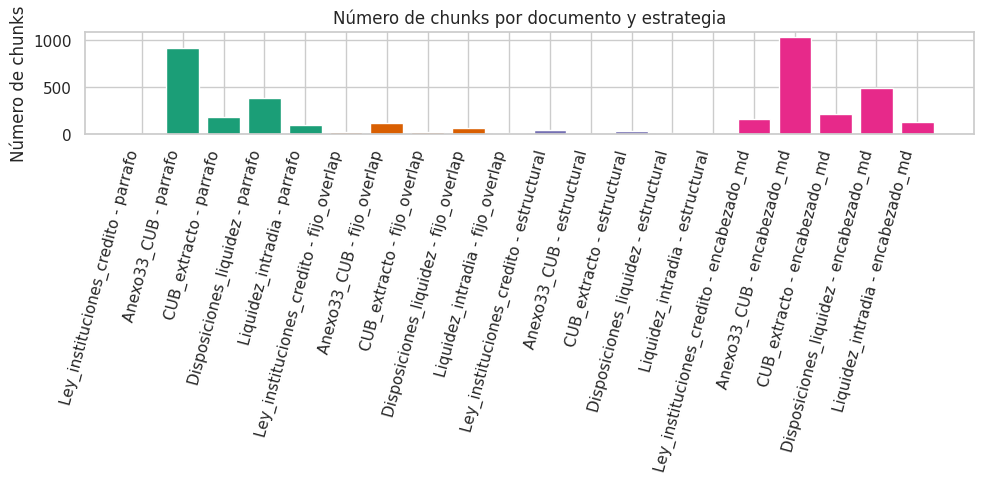

In [72]:
plt.figure(figsize=(10, 5))
for estrategia in df_chunking["estrategia"].unique():
    temp = df_chunking[df_chunking["estrategia"] == estrategia]
    plt.bar(temp["documento"] + " - " + estrategia, temp["n_chunks"])

plt.xticks(rotation=75, ha="right")
plt.title("Número de chunks por documento y estrategia")
plt.ylabel("Número de chunks")
plt.tight_layout()
plt.show()

Una vez evaluadas las distintas estrategias de fragmentación, se selecciona la técnica de chunking con mejor equilibrio entre preservación de contexto regulatorio, granularidad semántica y consistencia estructural.

Se seleccionó la estrategia de fragmentación por tamaño fijo "fijo_overlap" con solapamiento como estrategia base, ya que generó unidades de texto con longitud relativamente homogénea entre documentos. A diferencia del chunking por párrafo o estructural, evitó fragmentos excesivamente largos; y a diferencia del chunking por encabezados Markdown, redujo la generación de fragmentos demasiado pequeños. Esta estabilidad es importante para las etapas posteriores de vectorización y recuperación semántica.

### Dataset unificado para vectorización

 A partir de la técnica de chunking elegida se construye un dataset unificado orientado específicamente a tareas de vectorización y recuperación semántica.

El objetivo de esta etapa es integrar en una sola representación las diferentes fuentes de conocimiento utilizadas por el proyecto:

- documentos regulatorios fragmentados en chunks,
- estructuras de formularios,
- campos individuales,
- y catálogos regulatorios.

Cada registro consolidado se transforma en una unidad textual autocontenida acompañada de metadatos descriptivos como tipo de documento, sección regulatoria, catálogo asociado y longitud textual. Esta normalización permite que todas las entidades del ecosistema regulatorio puedan coexistir dentro de una misma base vectorial.

Desde la perspectiva de NLP, esta etapa constituye una forma de ingeniería de características semánticas, ya que transforma estructuras heterogéneas (texto libre, tablas regulatorias y formularios) en representaciones comparables dentro de un espacio vectorial común.

La construcción del dataset unificado facilita posteriormente:

- generación de embeddings,
- búsqueda semántica,
- recuperación contextual (RAG),
- asociación automática entre regulación y formularios,
- y detección de similitud conceptual entre estructuras regulatorias.

Además, la incorporación de metadatos estructurales permite conservar trazabilidad documental durante las etapas posteriores de indexación y recuperación.

**Formulario ML**

In [40]:
registros_texto_ml = []


for doc in docs_ml:
    chunks_ml = chunking_fijo_overlap(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_ml):
        registros_texto_ml.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk,
            "n_palabras": len(chunk.split())
        })



In [41]:
for i, row in df_campos_ml.iterrows():
    registros_texto_ml.append({
        "id": f"formulario_ml_campo_{i}",
        "tipo_documento": "campo_formulario_ml",
        "documento": "formulario_ml",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_ml.iterrows():
    registros_texto_ml.append({
        "id": f"catalogos_ml_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_ml",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_ml = pd.DataFrame(registros_texto_ml)
display(df_textos_ml.head())
display(df_textos_ml["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,None,None,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,None,None,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,None,None,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,None,None,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,None,None,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


,count
tipo_documento,
regulacion,352
campo_formulario_ml,35
catalogo,6


**Formulario FE**

In [42]:
registros_texto_fe = []


for doc in docs_fe:
    chunks_fe = chunking_fijo_overlap(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_fe):
        registros_texto_fe.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk,
            "n_palabras": len(chunk.split())
        })


In [43]:
for i, row in df_campos_fe.iterrows():
    registros_texto_fe.append({
        "id": f"formulario_fe_campo_{i}",
        "tipo_documento": "campo_formulario_fe",
        "documento": "formulario_fe",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_fe.iterrows():
    registros_texto_fe.append({
        "id": f"catalogos_fe_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_fe",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_fe = pd.DataFrame(registros_texto_fe)
display(df_textos_fe.head())
display(df_textos_fe["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,None,None,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,None,None,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,None,None,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,None,None,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,None,None,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


,count
tipo_documento,
regulacion,352
campo_formulario_fe,28
catalogo,6


**Formulario LID**

In [44]:
registros_texto_lid = []


for doc in docs_lid:
    chunks_lid = chunking_fijo_overlap(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_lid):
        registros_texto_lid.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk,
            "n_palabras": len(chunk.split())
        })

In [45]:
for i, row in df_campos_lid.iterrows():
    registros_texto_lid.append({
        "id": f"formulario_lid_campo_{i}",
        "tipo_documento": "campo_formulario_lid",
        "documento": "formulario_lid",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_lid.iterrows():
    registros_texto_lid.append({
        "id": f"catalogos_lid_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_lid",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_lid = pd.DataFrame(registros_texto_lid)
display(df_textos_lid.head())
display(df_textos_lid["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,None,None,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,None,None,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,None,None,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,None,None,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,None,None,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


,count
tipo_documento,
regulacion,273
campo_formulario_lid,50
catalogo,13


### Vectorización: Bag of Words, TF-IDF y Embeddings Semánticos

Como parte de la fase de ingeniería de características, se implementan distintas técnicas de vectorización textual con el objetivo de transformar el corpus regulatorio en representaciones numéricas utilizables por algoritmos de aprendizaje automático y sistemas de recuperación semántica.

En esta etapa se comparan tres enfoques ampliamente utilizados en NLP:

- **Bag of Words (BoW)**, que representa cada documento mediante frecuencias absolutas de términos.
- **TF-IDF (Term Frequency – Inverse Document Frequency)**, que pondera los términos según su relevancia relativa dentro del corpus completo.
- y **Embeddings semánticos**, que representan fragmentos completos de texto mediante vectores densos capaces de capturar relaciones semánticas y contexto conceptual entre documentos regulatorios.

Estas representaciones permiten cuantificar el contenido semántico de cada fragmento textual, formulario o catálogo mediante vectores numéricos de alta dimensionalidad. Desde la perspectiva de ingeniería de características, cada término, n-grama o embedding generado constituye una representación potencial del conocimiento regulatorio contenido en el corpus.

Para mejorar la calidad de las representaciones se aplican diversas decisiones de preprocesamiento y normalización, incluyendo:

- conversión a minúsculas,
- eliminación implícita de términos extremadamente raros o excesivamente frecuentes,
- incorporación de stopwords en español,
- generación de n-gramas para capturar relaciones terminológicas compuestas frecuentes en regulación financiera,
- y segmentación estructural mediante estrategias de chunking adaptadas a documentos regulatorios.

En el caso de los embeddings, se utiliza el modelo `text-embedding-3-small` de OpenAI debido a su buen balance entre costo, velocidad y capacidad semántica. Estos embeddings serán posteriormente almacenados en una base vectorial (ChromaDB) para soportar tareas de recuperación contextual tipo RAG (*Retrieval-Augmented Generation*).

El objetivo principal de esta fase es evaluar qué representación captura de mejor manera la semántica regulatoria y facilita tareas posteriores de búsqueda contextual, similitud documental, recuperación de información y generación automatizada de formularios regulatorios.

In [46]:
from src.nlp_core.vetorizacion import obtener_embeddings, indexar_documentos_formularios


In [48]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords_es = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [49]:
bow_vectorizer = CountVectorizer(
    lowercase=True,
    min_df=2,
    max_df=0.95,
    stop_words = stopwords_es,
    ngram_range=(1, 1)
)

In [50]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    min_df=2,
    max_df=0.95,
    stop_words = stopwords_es,
    ngram_range=(1, 2)
)

**Formulario ML**

In [54]:
import dotenv
dotenv_path = PROJECT_ROOT / "env.txt"
dotenv.load_dotenv(dotenv_path=dotenv_path)

corpus_ml = df_textos_ml["texto"].fillna("").astype(str).tolist()

X_bow_ml = bow_vectorizer.fit_transform(corpus_ml)

X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)



print("Dimensiones BoW Formulario ML:", X_bow_ml.shape)
print("Dimensiones TF-IDF Formulario ML:", X_tfidf_ml.shape)

Dimensiones BoW Formulario ML: (393, 3077)
Dimensiones TF-IDF Formulario ML: (393, 12829)


**Formulario FE**

In [60]:
corpus_fe = df_textos_fe["texto"].fillna("").astype(str).tolist()


X_bow_fe = bow_vectorizer.fit_transform(corpus_fe)

X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)


print("Dimensiones BoW Formulario FE:", X_bow_fe.shape)
print("Dimensiones TF-IDF Formulario FE:", X_tfidf_fe.shape)

Dimensiones BoW Formulario FE: (386, 3074)
Dimensiones TF-IDF Formulario FE: (386, 12830)


**Formulario LID**

In [56]:
corpus_lid = df_textos_lid["texto"].fillna("").astype(str).tolist()


X_bow_lid = bow_vectorizer.fit_transform(corpus_lid)

X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)



print("Dimensiones BoW Formulario LID:", X_bow_lid.shape)
print("Dimensiones TF-IDF Formulario LID:", X_tfidf_lid.shape)


Dimensiones BoW Formulario LID: (336, 2796)
Dimensiones TF-IDF Formulario LID: (336, 10411)


### Selección de características con TF-IDF

En el contexto de este proyecto, la técnica TF-IDF funciona no sólo como un método clásico de vectorización, sino también como una estrategia de selección de características (*feature selection*), ya que ayuda a identificar qué conceptos regulatorios contienen mayor capacidad informativa dentro del conjunto documental.

Desde la perspectiva de NLP aplicado a regulación financiera, esta etapa de selección resulta particularmente útil para separar términos genéricos de lenguaje administrativo (por ejemplo, “institución”, “información”, “fecha”) de conceptos más específicos asociados a reglas regulatorias, métricas financieras o estructuras operativas.

Además, esta representación servirá como baseline interpretable para comparar posteriormente métodos más avanzados de recuperación semántica, incluyendo embeddings densos, búsqueda vectorial y arquitecturas RAG basadas en modelos de lenguaje.

**Formulario ML**

In [57]:
X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
df_top_tfidf_ml = top_tfidf_terms(tfidf_vectorizer, X_tfidf_ml, top_n=20)
display(df_top_tfidf_ml)

,termino,score_promedio_tfidf
0,crédito,0.036403
1,financieros,0.035735
2,efectivo,0.031214
3,operaciones,0.027923
4,activos,0.027072
5,instrumentos,0.022322
6,instrumentos financieros,0.021838
7,monto,0.021475
8,entidad,0.019004
9,entidades,0.018763


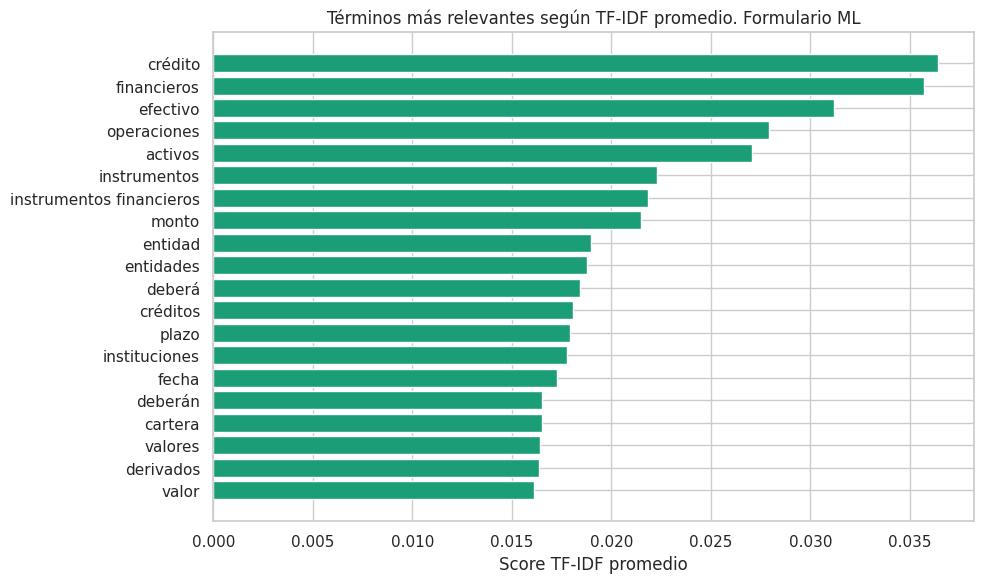

In [73]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_ml["termino"][::-1], df_top_tfidf_ml["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario ML")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

**Formulario FE**

In [74]:
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
df_top_tfidf_fe = top_tfidf_terms(tfidf_vectorizer, X_tfidf_fe, top_n=20)
display(df_top_tfidf_fe)

,termino,score_promedio_tfidf
0,crédito,0.036830
1,financieros,0.036057
2,efectivo,0.031647
3,operaciones,0.028165
4,activos,0.027522
5,instrumentos,0.022524
6,instrumentos financieros,0.022015
7,monto,0.021173
8,entidades,0.018960
9,deberá,0.018678


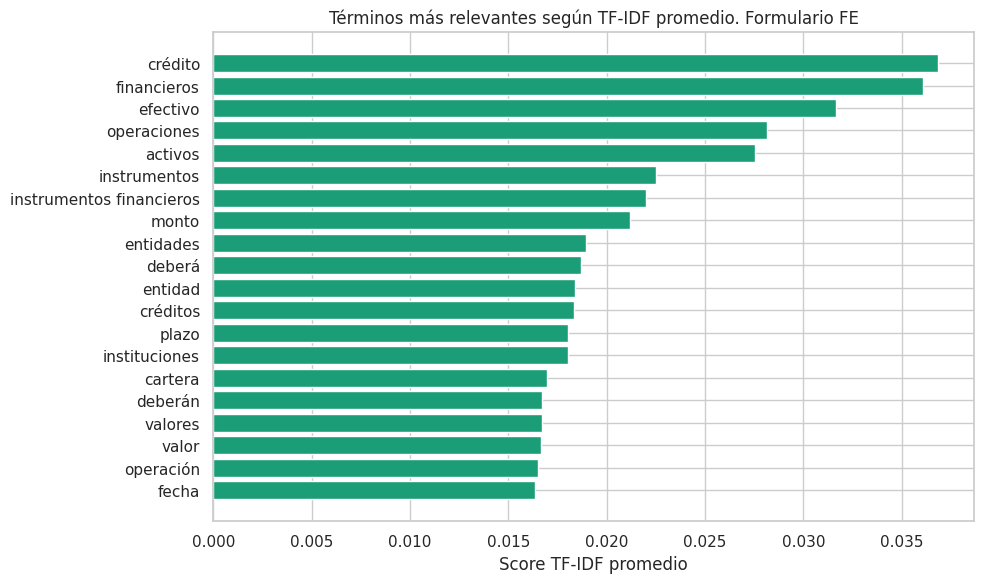

In [75]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_fe["termino"][::-1], df_top_tfidf_fe["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario FE")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

**Formulario LID**

In [63]:
X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)
df_top_tfidf_lid = top_tfidf_terms(tfidf_vectorizer, X_tfidf_lid, top_n=20)
display(df_top_tfidf_lid)

,termino,score_promedio_tfidf
0,crédito,0.038547
1,financieros,0.037838
2,efectivo,0.034984
3,fecha,0.028875
4,activos,0.025829
5,operaciones,0.025541
6,instrumentos,0.021499
7,instrumentos financieros,0.020903
8,entidad,0.019990
9,créditos,0.019660


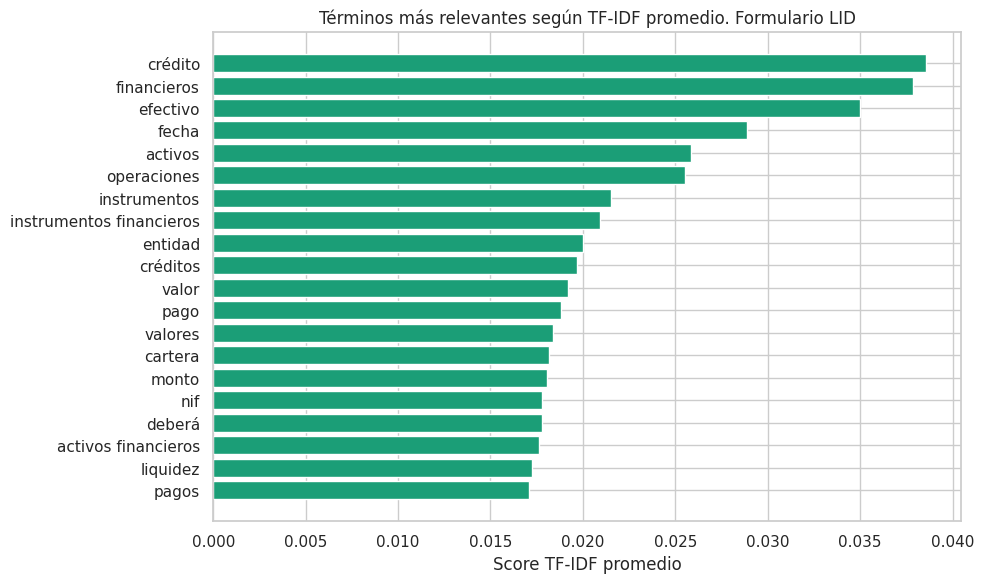

In [76]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_lid["termino"][::-1], df_top_tfidf_lid["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario LID")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

Los resultados de TF-IDF muestran que los tres formularios comparten un vocabulario financiero-regulatorio muy similar. En ML, FE y LID aparecen como términos más relevantes palabras como crédito, financieros, efectivo, operaciones, activos, instrumentos, monto y entidad. Esto indica que los documentos pertenecen a un mismo dominio conceptual y que la técnica logra identificar los principales conceptos asociados con instrumentos financieros, operaciones, recursos disponibles y características de las entidades reportantes.

Sin embargo, también se observan diferencias específicas. En FE aparecen términos como plazo, cartera y fecha, lo que sugiere una mayor relación con vencimientos o clasificación temporal de la información. En LID destacan además palabras como pago, pagos y liquidez, coherentes con el enfoque de liquidez intradía y flujos de pago. En conjunto, TF-IDF funciona como una primera aproximación interpretable para comparar formularios, aunque su alcance sigue limitado a la relevancia léxica y no necesariamente captura relaciones semánticas profundas entre los textos.

### Reducción dimensional con TruncatedSVD

Los modelos de vectorización textual, particularmente TF-IDF, generan espacios de representación de muy alta dimensionalidad donde cada término o n-grama constituye una característica independiente. Aunque estas representaciones conservan gran cantidad de información semántica, también incrementan la complejidad computacional y dificultan la interpretación de relaciones globales dentro del corpus.

Con el objetivo de reducir dimensionalidad y explorar la estructura latente de los documentos regulatorios, se aplica la técnica ***Truncated Singular Value Decomposition (TruncatedSVD)***, ampliamente utilizada en NLP para aproximar matrices dispersas de gran tamaño.

Esta técnica permite proyectar los documentos en un espacio semántico reducido donde patrones similares tienden a agruparse automáticamente. En términos prácticos, cada componente generado representa una combinación latente de términos frecuentes que captura parte de la variabilidad estructural del corpus.

La reducción dimensional resulta útil para:

- visualizar agrupamientos semánticos,
- detectar similitud entre documentos regulatorios,
- identificar posibles relaciones entre formularios y catálogos,
- reducir ruido en representaciones vectoriales,
- y facilitar tareas posteriores de clustering o recuperación semántica.

En el contexto del proyecto, este análisis permite explorar si distintas entidades documentales (chunks regulatorios, formularios y catálogos) comienzan a organizarse naturalmente en regiones semánticas diferenciadas dentro del espacio vectorial generado a partir de TF-IDF.

**Formulario ML**

In [65]:
svd_ml = TruncatedSVD(n_components=2, random_state=42)
X_svd_ml = svd_ml.fit_transform(X_tfidf_ml)

df_textos_ml["svd_1"] = X_svd_ml[:, 0]
df_textos_ml["svd_2"] = X_svd_ml[:, 1]

print("Varianza explicada:", svd_ml.explained_variance_ratio_.sum())

Varianza explicada: 0.028519563373439326


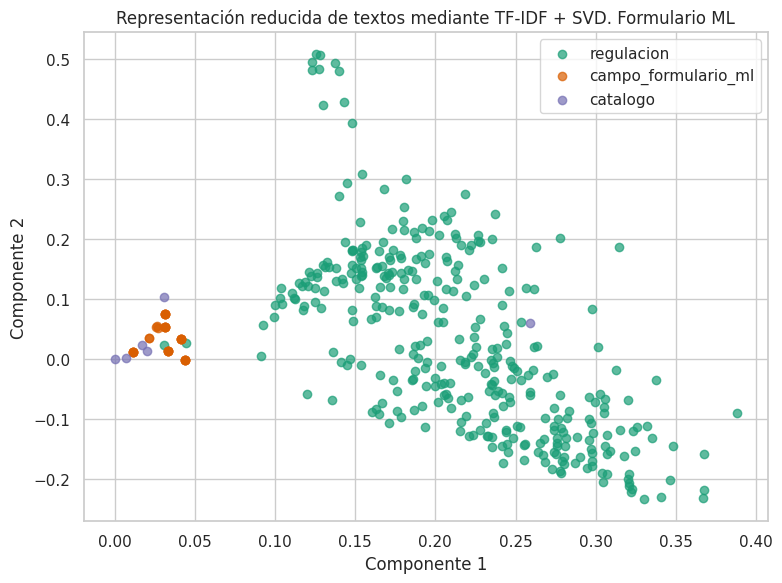

In [77]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_ml["tipo_documento"].unique():
    temp_ml = df_textos_ml[df_textos_ml["tipo_documento"] == tipo]
    plt.scatter(temp_ml["svd_1"], temp_ml["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario ML")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

**Formulario FE**

In [78]:
svd_fe = TruncatedSVD(n_components=2, random_state=42)
X_svd_fe = svd_fe.fit_transform(X_tfidf_fe)

df_textos_fe["svd_1"] = X_svd_fe[:, 0]
df_textos_fe["svd_2"] = X_svd_fe[:, 1]

print("Varianza explicada:", svd_fe.explained_variance_ratio_.sum())

Varianza explicada: 0.02872604379276874


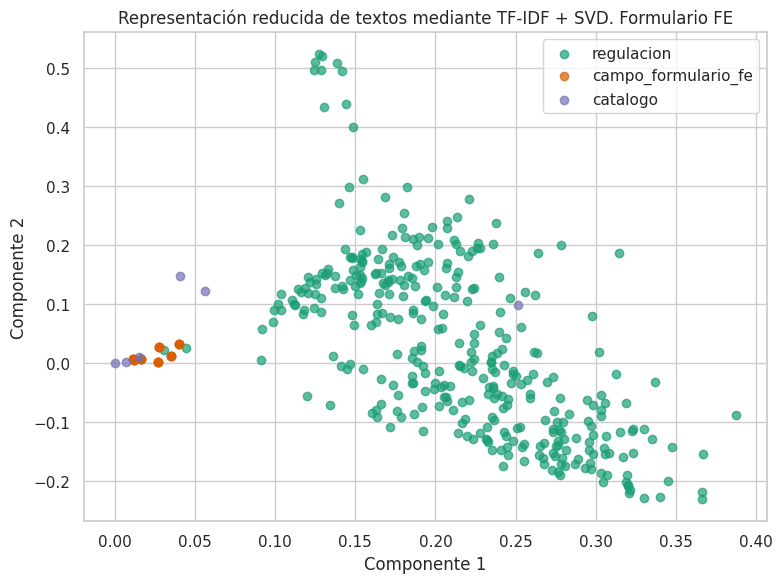

In [79]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_fe["tipo_documento"].unique():
    temp_fe = df_textos_fe[df_textos_fe["tipo_documento"] == tipo]
    plt.scatter(temp_fe["svd_1"], temp_fe["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario FE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

**Formulario LID**

In [80]:
svd_lid = TruncatedSVD(n_components=2, random_state=42)
X_svd_lid = svd_lid.fit_transform(X_tfidf_lid)

df_textos_lid["svd_1"] = X_svd_lid[:, 0]
df_textos_lid["svd_2"] = X_svd_lid[:, 1]

print("Varianza explicada:", svd_lid.explained_variance_ratio_.sum())

Varianza explicada: 0.03359076676779548


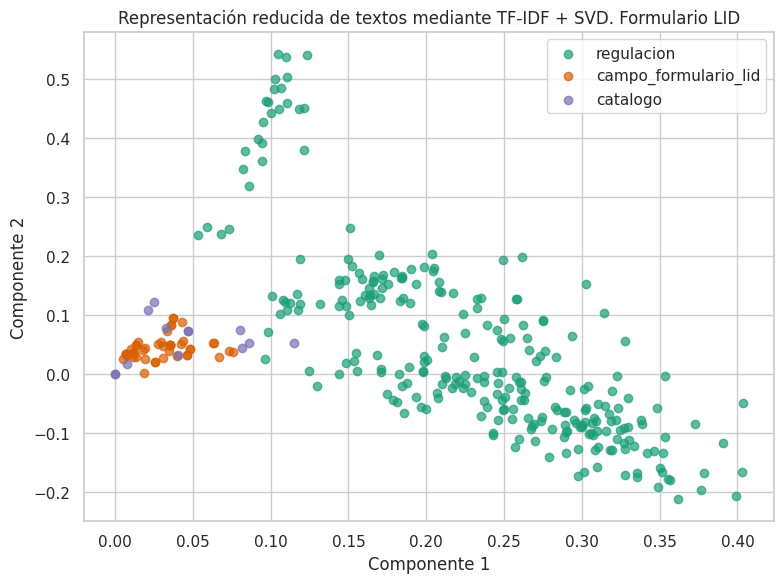

In [81]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_lid["tipo_documento"].unique():
    temp_lid = df_textos_lid[df_textos_lid["tipo_documento"] == tipo]
    plt.scatter(temp_lid["svd_1"], temp_lid["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario LID")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

La reducción dimensional con TruncatedSVD muestra que los tres formularios presentan una estructura muy parecida: los textos de regulación se distribuyen ampliamente en el espacio reducido, mientras que los campos de formulario y catálogos aparecen mucho más concentrados cerca del origen. Esto sugiere que los documentos regulatorios tienen mayor diversidad temática y léxica, mientras que los formularios y catálogos son más breves, estructurados y homogéneos. La varianza explicada por los dos componentes es baja en los tres casos, alrededor de 2.8% en ML y FE, y 3.3% en LID, lo cual es esperable en matrices TF-IDF de alta dimensionalidad, donde la información se reparte entre muchos términos.

En comparación, el formulario LID muestra una separación ligeramente más clara entre algunos grupos de regulación y los elementos de formulario/catálogo, además de una varianza explicada un poco mayor. Esto puede indicar que sus textos contienen patrones léxicos algo más diferenciados, probablemente asociados con pagos, liquidez y operaciones intradía. En conjunto, el análisis permite visualizar relaciones generales entre los documentos, pero no debe interpretarse como una separación definitiva de temas, sino como una exploración inicial de la estructura latente del corpus antes de aplicar métodos semánticos más robustos como embeddings o búsqueda vectorial.

### Búsqueda de similitud con TF-IDF

Una vez generadas las representaciones vectoriales del corpus, es posible realizar búsquedas de similitud semántica para recuperar fragmentos regulatorios, estructuras de formularios y catálogos relacionados con una necesidad funcional específica.

A diferencia de las búsquedas tradicionales basadas únicamente en coincidencias exactas de palabras clave, este enfoque utiliza la representación TF-IDF para identificar documentos que compartan contexto terminológico y proximidad conceptual dentro del espacio vectorial.

En el contexto del proyecto, estas consultas simulan escenarios reales de diseño regulatorio, donde un analista necesita identificar campos potenciales para un nuevo formulario, reglas regulatorias asociadas, catálogos relacionados o estructuras previamente utilizadas en otros requerimientos normativos.

El objetivo principal de esta etapa es evaluar si las representaciones construidas durante la ingeniería de características logran preservar suficiente información semántica para apoyar tareas posteriores de recuperación contextual y generación automatizada de formularios regulatorios.

#### Ejemplos de consultas semánticas

Las siguientes consultas simulan necesidades funcionales reales durante el diseño de formularios regulatorios. En lugar de buscar palabras exactas, las búsquedas intentan recuperar fragmentos normativos y estructuras existentes relacionadas con conceptos regulatorios, variables potenciales y requerimientos de información.



**Formulario ML**

- "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"
- "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"



In [84]:
consulta = "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"

X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
resultados_tfidf_ml_1 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_ml,
    df_textos_ml,
    k=5
)

display(resultados_tfidf_ml_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
249,Disposiciones_liquidez_chunk_2,regulacion,Disposiciones_liquidez,None,None,0.208294,de descuento C D Grupo de Nivel I A1 B1 0 C1 D1 Grupo de Nivel IIA A2 B2 15 C2 D2 Grupo de Nivel IIB correspondiente...
328,Disposiciones_liquidez_chunk_81,regulacion,Disposiciones_liquidez,None,None,0.167072,B Los títulos acciones y créditos recibidos en operaciones de reporto o préstamo que a su vez se hayan restringido u...
248,Disposiciones_liquidez_chunk_1,regulacion,Disposiciones_liquidez,None,None,0.155624,de internet dentro del mes inmediato siguiente a la fecha en que las Instituciones deban realizar la difusión a que ...
329,Disposiciones_liquidez_chunk_82,regulacion,Disposiciones_liquidez,None,None,0.149833,como Activos Líquidos Elegibles que pertenecen al grupo de nivel IIA de conformidad con las presentes disposiciones ...
74,Anexo33_CUB_chunk_37,regulacion,Anexo33_CUB,None,None,0.129473,especiales Pág 19 Revelaciones relativas a la determinación del valor razonable Las entidades respecto del Precio Ac...


In [85]:
consulta = "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"


X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
resultados_tfidf_ml_2 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_ml,
    df_textos_ml,
    k=5
)

display(resultados_tfidf_ml_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
304,Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,None,None,0.202492,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
302,Disposiciones_liquidez_chunk_55,regulacion,Disposiciones_liquidez,None,None,0.186199,operaciones no señaladas anteriormente como un flujo contractual de entrada 100 Para propósitos de este anexo se ent...
303,Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,None,None,0.173864,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...
228,Anexo33_CUB_chunk_191,regulacion,Anexo33_CUB,None,None,0.138662,El estado de flujos de efectivo tiene como objetivo principal proporcionar a los usuarios de los estados financieros...
121,Anexo33_CUB_chunk_84,regulacion,Anexo33_CUB,None,None,0.128338,no está asegurada o que solo está garantizada por una parte relacionada del mismo Normas de reconocimiento y valuaci...


**Formulario FE**

- "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
- "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

Estas consultas permiten evaluar la capacidad de las estrategias de fragmentación y vectorización para preservar contexto regulatorio y recuperar información útil para futuras tareas de generación automatizada de formularios.



In [116]:
consulta = "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
resultados_tfidf_fe_1 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_fe,
    df_textos_fe,
    k=5
)

display(resultados_tfidf_fe_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
339,Disposiciones_liquidez_chunk_92,regulacion,Disposiciones_liquidez,None,None,0.289533,el monto que corresponda a las operaciones con instrumentos derivados cuando el costo actual de reemplazo en los tér...
270,Disposiciones_liquidez_chunk_23,regulacion,Disposiciones_liquidez,None,None,0.265072,de III En el escenario V además de las medidas aplicables a las Instituciones que se ubiquen en el escenario IV la s...
327,Disposiciones_liquidez_chunk_80,regulacion,Disposiciones_liquidez,None,None,0.225660,posiciones pasivas de las operaciones con instrumentos financieros derivados es decir cuando su costo de remplazo se...
320,Disposiciones_liquidez_chunk_73,regulacion,Disposiciones_liquidez,None,None,0.216467,Para el presente anexo solo deberán tomarse en cuenta los activos que no estén otorgados en garantía ni sujetos a re...
276,Disposiciones_liquidez_chunk_29,regulacion,Disposiciones_liquidez,None,None,0.214253,la Comisión ordene modificaciones al plan de restauración de que se trate este deberá presentarse nuevamente para su...


In [117]:
consulta = "Generar variables para clasificar pasivos según estabilidad y plazo contractual"
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
resultados_tfidf_fe_2 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_fe,
    df_textos_fe,
    k=5
)

display(resultados_tfidf_fe_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
128,Anexo33_CUB_chunk_91,regulacion,Anexo33_CUB,None,None,0.086490,los flujos de efectivo futuros estimados que se recibirán por principal e intereses conforme al esquema de pagos pac...
318,Disposiciones_liquidez_chunk_71,regulacion,Disposiciones_liquidez,None,None,0.072643,un año C Los pasivos con plazo residual igual o mayor a un año II Pasivos con ponderación del 95 A Depósitos a la vi...
125,Anexo33_CUB_chunk_88,regulacion,Anexo33_CUB,None,None,0.063197,cartera de crédito al momento de la transacción Cualquier otro gasto que no esté asociado al otorgamiento del crédit...
204,Anexo33_CUB_chunk_167,regulacion,Anexo33_CUB,None,None,0.059163,de exigibilidad inmediata de corto plazo monto de las amortizaciones cuyo plazo por vencer sea menor o igual a un añ...
252,Disposiciones_liquidez_chunk_5,regulacion,Disposiciones_liquidez,None,None,0.058133,de dichas operaciones III Tratándose de las emisiones de la propia Institución cuyo plazo remanente sea mayor a trei...


**Formulario LID**

- "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"
- "Identificar requerimientos relacionados con obligaciones de pago intradía"


In [87]:
consulta = "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"

X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)
resultados_tfidf_lid_1 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_lid,
    df_textos_lid,
    k=5
)

display(resultados_tfidf_lid_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
271,Liquidez_intradia_chunk_24,regulacion,Liquidez_intradia,None,None,0.329947,especialmente cuando su monto de liquidez intradía disponible al inicio del día hábil suele ser bajo En tales circun...
277,formulario_lid_campo_4,campo_formulario_lid,formulario_lid,seccion_I_liquiddisp_inicio_dia,None,0.292855,saldo | saldo disponible al inicio del dia | numerico |
255,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,None,None,0.289280,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
254,Liquidez_intradia_chunk_7,regulacion,Liquidez_intradia,None,None,0.271474,algún momento intradía necesitará acceso a liquidez intradía para financiar ese saldo El monto mínimo de liquidez in...
260,Liquidez_intradia_chunk_13,regulacion,Liquidez_intradia,None,None,0.204749,capacidad para obtener liquidez intradía de su s banco s corresponsal es 36 Los bancos que gestionan liquidez intrad...


In [88]:
consulta = "Identificar requerimientos relacionados con obligaciones de pago intradía"

resultados_tfidf_lid_2 = buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_lid,
    df_textos_lid,
    k=5
)

display(resultados_tfidf_lid_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
327,catalogos_lid_identificador_pago,catalogo,catalogos_lid,None,identificador_pago,0.529906,Sin obligaciones de pago Con obligaciones de pago
328,catalogos_lid_identificador_liquidacion,catalogo,catalogos_lid,None,identificador_liquidacion,0.529906,Sin obligaciones de pago Con obligaciones de pago
247,Liquidez_intradia_chunk_0,regulacion,Liquidez_intradia,None,None,0.191346,Herramientas de monitoreo para la gestión de la liquidez intradía Abril de 2013 bis org Contenido I Introducción 1 L...
250,Liquidez_intradia_chunk_3,regulacion,Liquidez_intradia,None,None,0.169354,Sección III Los escenarios de tensión de liquidez intradía Sección IV El alcance de aplicación de las herramientas S...
248,Liquidez_intradia_chunk_1,regulacion,Liquidez_intradia,None,None,0.168783,intradía suficiente para cumplir sus objetivos intradía iv Tener la capacidad de gestionar y movilizar colateral seg...


a búsqueda de similitud con TF-IDF muestra resultados mixtos. En varios casos, el método recupera fragmentos conceptualmente relacionados con las consultas, especialmente cuando existe coincidencia directa de términos relevantes. Por ejemplo, en LID, las consultas sobre fuentes de liquidez disponible al inicio del día y obligaciones de pago intradía recuperan resultados muy coherentes, incluyendo fragmentos de regulación, campos del formulario y catálogos directamente asociados con liquidez intradía, pagos y obligaciones. Esto indica que TF-IDF puede ser útil para localizar información cuando la consulta comparte vocabulario específico con los documentos.

Sin embargo, en los formularios ML y FE los resultados parecen depender más de coincidencias léxicas que de una comprensión semántica profunda. Algunas consultas recuperan fragmentos relacionados de forma general con crédito, activos, flujos, pasivos o instrumentos financieros, pero no siempre responden exactamente a la intención de la búsqueda. Esto confirma que TF-IDF funciona como una primera aproximación interpretable para recuperación de información, aunque puede ser limitado cuando la consulta usa palabras distintas a las del documento o cuando se requiere entender relaciones conceptuales más complejas. Por ello, estos resultados sirven como línea base para comparar posteriormente con embeddings semánticos y ChromaDB.

## Búsqueda de similitud semántica con Embeddings y ChromaDB

Además de la representación TF-IDF, se implementa una búsqueda semántica basada en embeddings densos almacenados en ChromaDB. A diferencia de TF-IDF, que depende principalmente de coincidencias léxicas y ponderación de términos, los embeddings permiten representar fragmentos regulatorios, campos de formularios y catálogos en un espacio vectorial semántico.

Este enfoque permite recuperar información relacionada conceptualmente aunque las palabras utilizadas en la consulta no coincidan exactamente con las del documento. Por ello, resulta especialmente útil en este proyecto, donde un analista puede describir una necesidad funcional con lenguaje natural y esperar que el sistema recupere fragmentos normativos, campos o catálogos relevantes.

En esta sección se utilizan las mismas consultas empleadas en la búsqueda con TF-IDF para comparar si la representación semántica recupera resultados más cercanos al sentido funcional de cada caso.


A continuación se realiza la indexación de los datasets unificados de cada formulario utilizando ChromaDB. Cada colección vectorial contiene documentos regulatorios, campos de formulario y catálogos representados mediante embeddings semánticos.

Se ejecutan las mismas consultas utilizadas en la sección de TF-IDF. El objetivo es comparar si la búsqueda semántica basada en embeddings permite recuperar fragmentos con mayor cercanía conceptual, incluso cuando no existe coincidencia exacta de términos.

In [90]:
X_chroma_ml = indexar_documentos_formularios(df_textos_ml, collection_name = "regulacion_formulario_ml")

X_chroma_fe = indexar_documentos_formularios(df_textos_fe, collection_name = "regulacion_formulario_fe")

X_chroma_lid = indexar_documentos_formularios(df_textos_lid, collection_name = "regulacion_formulario_lid")

"Base vectorial creada correctamente y almacenada en" /content/data/03_output/chroma_db
"Base vectorial creada correctamente y almacenada en" /content/data/03_output/chroma_db


Se importa la función personalizada creada para este cometido

In [ ]:
from src.nlp_core.vectorizacion import buscar_similitud_chroma

**Formulario ML**

Consultas utilizadas:

- "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"
- "Identificar información necesaria para obtener los ponderadores de las entradas de efectivo de la cartera de crédito por tipo de contraparte"

In [99]:
consulta_ml_1 = "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"

resultados_chroma_ml_1_df, _ = buscar_similitud_chroma(
    query=consulta_ml_1,
    vectorstore=X_chroma_ml,
    k=5
)

display(resultados_chroma_ml_1_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.861925,Disposiciones_liquidez_chunk_3,regulacion,Disposiciones_liquidez,None,None,None,dentro de la clasificación de Activos Líquidos Elegibles este podrá seguir computando en su clasificación original d...
1,2,0.866409,Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,None,None,None,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
2,3,0.870579,Disposiciones_liquidez_chunk_1,regulacion,Disposiciones_liquidez,None,None,None,de internet dentro del mes inmediato siguiente a la fecha en que las Instituciones deban realizar la difusión a que ...
3,4,0.873386,Disposiciones_liquidez_chunk_50,regulacion,Disposiciones_liquidez,None,None,None,operaciones de compra venta de títulos fecha valor cuando resulte una posición pasiva una vez compensada la parte ac...
4,5,0.877078,Disposiciones_liquidez_chunk_2,regulacion,Disposiciones_liquidez,None,None,None,de descuento C D Grupo de Nivel I A1 B1 0 C1 D1 Grupo de Nivel IIA A2 B2 15 C2 D2 Grupo de Nivel IIB correspondiente...


In [100]:
consulta_ml_2 =  "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"

resultados_chroma_ml_2_df, _ = buscar_similitud_chroma(
    query=consulta_ml_2,
    vectorstore=X_chroma_ml,
    k=5
)

display(resultados_chroma_ml_2_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.765215,Anexo33_CUB_chunk_89,regulacion,Anexo33_CUB,None,None,None,efectivo Deduciendo de los flujos de efectivo futuros estimados a recibir determinados conforme al numeral anterior ...
1,2,0.794822,Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,None,None,None,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
2,3,0.805385,Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,None,None,None,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
3,4,0.810149,Disposiciones_liquidez_chunk_91,regulacion,Disposiciones_liquidez,None,None,None,35 de acuerdo al Método Estándar para riesgo de crédito de Basilea II 22 Cartera de crédito de vivienda en etapas 1 ...
4,5,0.819939,Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,None,None,None,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...


**Formulario FE**

Consultas utilizadas:

- "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
- "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

In [118]:
consulta_fe_1 = "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"

resultados_chroma_fe_1_df, _ = buscar_similitud_chroma(
    query=consulta_fe_1,
    vectorstore=X_chroma_fe,
    k=5
)

display(resultados_chroma_fe_1_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.662168,Disposiciones_liquidez_chunk_69,regulacion,Disposiciones_liquidez,None,None,None,consorcio o grupo empresarial que de acuerdo con las Políticas y Criterios el consejo de administración de la Instit...
1,2,0.697013,Disposiciones_liquidez_chunk_87,regulacion,Disposiciones_liquidez,None,None,None,cálculo de los referidos promedios trimestrales las Instituciones deberán utilizar los importes y coeficientes que h...
2,3,0.717540,Disposiciones_liquidez_chunk_80,regulacion,Disposiciones_liquidez,None,None,None,posiciones pasivas de las operaciones con instrumentos financieros derivados es decir cuando su costo de remplazo se...
3,4,0.740209,Disposiciones_liquidez_chunk_90,regulacion,Disposiciones_liquidez,None,None,None,Operaciones Interdependientes 11 Suma de la referencia 12 y referencia 13 12 El monto que corresponda a las operacio...
4,5,0.740998,Disposiciones_liquidez_chunk_88,regulacion,Disposiciones_liquidez,None,None,None,de Financiamiento Estable Neto No aplica No aplica No aplica No aplica No aplica No aplica No aplica No aplica 16 De...


In [102]:
consulta_fe_2 = "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

resultados_chroma_fe_2_df, _ = buscar_similitud_chroma(
    query=consulta_fe_2,
    vectorstore=X_chroma_fe,
    k=5
)

display(resultados_chroma_fe_2_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.911674,Anexo33_CUB_chunk_172,regulacion,Anexo33_CUB,None,None,None,empresarial o comercial Acredores por liquidación de operaciones Emittentes financieros Acredores por cuentas de mar...
1,2,0.930384,Disposiciones_liquidez_chunk_70,regulacion,Disposiciones_liquidez,None,None,None,Financiamiento Estable Disponible Las Instituciones para determinar el Monto de Financiamiento Estable Disponible de...
2,3,0.932079,Disposiciones_liquidez_chunk_50,regulacion,Disposiciones_liquidez,None,None,None,operaciones de compra venta de títulos fecha valor cuando resulte una posición pasiva una vez compensada la parte ac...
3,4,0.947278,Disposiciones_liquidez_chunk_71,regulacion,Disposiciones_liquidez,None,None,None,un año C Los pasivos con plazo residual igual o mayor a un año II Pasivos con ponderación del 95 A Depósitos a la vi...
4,5,0.971382,Disposiciones_liquidez_chunk_84,regulacion,Disposiciones_liquidez,None,None,None,contemplada en el contrato El contrato marco no deberá permitir que en caso de incumplimiento de una de las partes l...


**Formulario LID**

Consultas utilizadas:

- "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"
- "Identificar requerimientos relacionados con obligaciones de pago intradía"

In [103]:
consulta_lid_1 = "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"

resultados_chroma_lid_1_df, _ = buscar_similitud_chroma(
    query=consulta_lid_1,
    vectorstore=X_chroma_lid,
    k=5
)

display(resultados_chroma_lid_1_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.761304,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,None,None,None,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
1,2,0.792903,Liquidez_intradia_chunk_7,regulacion,Liquidez_intradia,None,None,None,algún momento intradía necesitará acceso a liquidez intradía para financiar ese saldo El monto mínimo de liquidez in...
2,3,0.814933,Liquidez_intradia_chunk_3,regulacion,Liquidez_intradia,None,None,None,Sección III Los escenarios de tensión de liquidez intradía Sección IV El alcance de aplicación de las herramientas S...
3,4,0.832109,Liquidez_intradia_chunk_5,regulacion,Liquidez_intradia,None,None,None,lograrlo se desarrollaron siete herramientas de monitoreo separadas véase el Cuadro 1 Como no todas las herramientas...
4,5,0.835031,Liquidez_intradia_chunk_4,regulacion,Liquidez_intradia,None,None,None,libremente en liquidez intradía Líneas de crédito garantizadas y no garantizadas comprometidas y no comprometidas di...


In [104]:
consulta_lid_2 = "Identificar requerimientos relacionados con obligaciones de pago intradía"

resultados_chroma_lid_2_df, _ = buscar_similitud_chroma(
    query=consulta_lid_2,
    vectorstore=X_chroma_lid,
    k=5
)

display(resultados_chroma_lid_2_df)

,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.758841,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,None,None,None,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
1,2,0.766201,Liquidez_intradia_chunk_9,regulacion,Liquidez_intradia,None,None,None,pagos brutos enviados y recibidos durante el periodo de reporte así como la cifra promedio diaria de pagos brutos re...
2,3,0.786176,Liquidez_intradia_chunk_24,regulacion,Liquidez_intradia,None,None,None,especialmente cuando su monto de liquidez intradía disponible al inicio del día hábil suele ser bajo En tales circun...
3,4,0.806420,Liquidez_intradia_chunk_20,regulacion,Liquidez_intradia,None,None,None,unidades Pagos brutos recibidos 200 400 300 350 150 1 400 unidades A iv Obligaciones con horario específico 200 valo...
4,5,0.831127,Liquidez_intradia_chunk_4,regulacion,Liquidez_intradia,None,None,None,libremente en liquidez intradía Líneas de crédito garantizadas y no garantizadas comprometidas y no comprometidas di...


La búsqueda semántica con embeddings y ChromaDB muestra una recuperación más flexible que TF-IDF, ya que no depende únicamente de coincidencias exactas entre palabras. En los formularios ML y FE, los resultados recuperan fragmentos relacionados con activos líquidos, flujos de efectivo, financiamiento estable, derivados, posiciones y pasivos, lo cual indica que el modelo logra asociar la intención general de las consultas con conceptos regulatorios cercanos, aunque no siempre devuelve campos específicos del formulario. Esto sugiere una mejora en la recuperación conceptual, pero también evidencia que algunos resultados siguen siendo amplios o indirectos.

En el caso de LID, los resultados son más consistentes y cercanos a las consultas planteadas. Para búsquedas sobre fuentes de liquidez al inicio del día y obligaciones de pago intradía, ChromaDB recupera fragmentos directamente relacionados con liquidez intradía, pagos, obligaciones, saldos disponibles y líneas de crédito. Esto indica que los embeddings capturan mejor el contexto funcional del formulario, especialmente cuando el dominio semántico está bien delimitado. En conjunto, este enfoque resulta más adecuado que TF-IDF para tareas posteriores de recuperación contextual y generación asistida de formularios regulatorios.

### Comparación final de resultados

A continuación se presenta una tabla con los resultados de la comparación de modelos utilizados para la base vectorial específica del formulario ML pero que representa los resultados de todos los formularios.

In [128]:
resumen_representaciones_ml = pd.DataFrame({
    "representacion": [
        "Bag of Words",
        "TF-IDF unigramas + bigramas",
        "TF-IDF + SVD",
        "Embeddings semánticos"
    ],
    "dimensionalidad": [
        X_bow_ml.shape[1],
        X_tfidf_ml.shape[1],
        2,
        "1536 en el caso de text-embedding-3-small"
    ],
    "ventaja": [
        "Simple e interpretable",
        "Pondera relevancia de términos",
        "Permite visualización y reducción de dimensión",
        "Captura similitud semántica"
    ],
    "uso_en_proyecto": [
        "Baseline",
        "Baseline principal de recuperación",
        "Exploración visual",
        "Modelo alternativo baseline de paga"
    ]
})

display(resumen_representaciones_ml)

,representacion,dimensionalidad,ventaja,uso_en_proyecto
0,Bag of Words,3077,Simple e interpretable,Baseline
1,TF-IDF unigramas + bigramas,12829,Pondera relevancia de términos,Baseline principal de recuperación
2,TF-IDF + SVD,2,Permite visualización y reducción de dimensión,Exploración visual
3,Embeddings semánticos,1536 en el caso de text-embedding-3-small,Captura similitud semántica,Modelo alternativo baseline de paga


## Conclusiones


En conjunto, los resultados muestran que las distintas representaciones vectoriales aportan niveles diferentes de utilidad para el análisis y recuperación de información regulatoria. Las representaciones basadas en Bag of Words y TF-IDF permiten transformar los textos en matrices numéricas interpretables, donde cada término o combinación de términos funciona como una característica del corpus. En particular, TF-IDF resultó útil para identificar los conceptos más representativos de cada formulario, mostrando que ML, FE y LID comparten una base común de vocabulario financiero-regulatorio, con términos como crédito, financieros, efectivo, operaciones, activos, instrumentos, monto y entidad. Al mismo tiempo, permitió observar diferencias temáticas relevantes, como la presencia de plazo y cartera en FE, o pago, pagos y liquidez en LID.

La reducción dimensional mediante TruncatedSVD permitió complementar este análisis al proyectar las representaciones TF-IDF en un espacio reducido de dos componentes. Aunque la varianza explicada fue baja, lo cual es esperable en matrices textuales de alta dimensionalidad, las gráficas ayudaron a visualizar la estructura general del corpus. En los tres formularios se observó que los textos regulatorios presentan una mayor dispersión, mientras que los campos de formulario y catálogos se concentran en regiones más cercanas al origen. Esto sugiere que los documentos regulatorios contienen una mayor diversidad léxica y conceptual, mientras que los formularios y catálogos son más estructurados y homogéneos. En el caso de LID, la separación visual parece ligeramente más clara, lo cual puede estar relacionado con un dominio más específico vinculado a liquidez intradía, pagos y obligaciones.

Respecto a la búsqueda de similitud con TF-IDF, los resultados muestran que esta técnica puede funcionar como una línea base útil cuando las consultas contienen términos cercanos o coincidentes con los documentos. Esto se observó especialmente en LID, donde las búsquedas sobre fuentes de liquidez disponible y obligaciones de pago intradía recuperaron fragmentos bastante coherentes. Sin embargo, en ML y FE algunos resultados fueron más generales o indirectos, lo que evidencia una limitación importante: TF-IDF identifica similitud principalmente a partir de coincidencias léxicas y ponderación de términos, pero no necesariamente comprende la intención completa de la consulta ni relaciones semánticas más profundas.

Por otro lado, la búsqueda con embeddings semánticos y ChromaDB mostró una recuperación más flexible y conceptualmente cercana, ya que no depende exclusivamente de que las palabras de la consulta aparezcan de forma exacta en los documentos. En ML y FE, los resultados recuperaron fragmentos relacionados con activos líquidos, flujos de efectivo, financiamiento estable, derivados, pasivos y posiciones financieras, lo cual indica que el modelo logra capturar asociaciones semánticas relevantes. En LID, los resultados fueron particularmente consistentes, recuperando información directamente relacionada con liquidez intradía, saldos disponibles, pagos, obligaciones y líneas de crédito. Esto confirma que los embeddings son más adecuados para tareas donde el usuario puede formular preguntas en lenguaje natural y esperar respuestas basadas en significado, no sólo en coincidencia de términos.

A partir de la comparación final, puede concluirse que TF-IDF sigue siendo valioso como método interpretable y como línea base, especialmente para selección de características, análisis exploratorio y comparación léxica entre documentos. Sin embargo, su alta dimensionalidad y dependencia de términos específicos limitan su desempeño en tareas de recuperación contextual más complejas. TruncatedSVD ayuda a visualizar patrones generales, pero su utilidad principal es exploratoria. En contraste, los embeddings semánticos reducen drásticamente la dimensionalidad de la representación —por ejemplo, a 153 dimensiones en el caso del modelo utilizado— y capturan mejor la similitud conceptual entre consultas y fragmentos documentales.

En términos del proyecto, estos resultados respaldan el uso de una arquitectura basada en embeddings y base vectorial para etapas posteriores de recuperación de contexto y generación automatizada de formularios regulatorios. Mientras que TF-IDF permite entender qué términos dominan cada corpus, ChromaDB permite recuperar fragmentos más útiles para alimentar un sistema RAG o un asistente de diseño regulatorio. Por ello, la estrategia más conveniente no es descartar los métodos clásicos, sino utilizarlos de manera complementaria: TF-IDF para diagnóstico, trazabilidad e interpretación del corpus, y embeddings semánticos para recuperación contextual, similitud documental y soporte a tareas generativas más avanzadas.